---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.

In [ ]:
#@title Identificação
Nome_1 = "Daniel Duarte" #@param {type:"string"}
RM_1 = "562508" #@param {type:"string"}
Nome_2 = "Felippe Nascimento" #@param {type:"string"}
RM_2 = "562123" #@param {type:"string"}
Nome_3 = "Matheus Hideki" #@param {type:"string"}
RM_3 = "564970" #@param {type:"string"}
Nome_4 = "Kawan Oliveira" #@param {type:"string"}
RM_4 = "562197" #@param {type:"string"}
Nome_5 = "Artur Rodrigues" #@param {type:"string"}
RM_5 = "564309" #@param {type:"string"}

for i in range(1, 6):
    nome, rm = globals()[f"Nome_{i}"], globals()[f"RM_{i}"]
    if nome:
        print(f"Integrante {i}: {nome} — RM {rm}")

Integrante 1: Daniel Duarte — RM 562508


---

## **Resumo do projeto**

**Problema:** prever se um cliente de uma operadora de telecomunicações vai **cancelar o serviço (churn)**.
**Base:** Telco Customer Churn (IBM) — 7.043 clientes, 21 colunas. **Tarefa:** classificação binária.
**Métrica principal:** ROC-AUC. **Modelos:** Random Forest, XGBoost e LightGBM, com Grid Search e Optuna.

**Estrutura do repositório:** `Checkpoint05_RF_XGBoost_LightGBM.ipynb` (este notebook) · `app.py` (Streamlit) · `model/pipeline_final.joblib` (pipeline final) · `data/` (base e casos de consistência) · `tests/test_paridade.py` · `requirements.txt` · `README.md`.

<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [ ]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: Latin Modern Roman


In [ ]:
# instala (se faltar) e importa as bibliotecas de machine learning
import importlib.util, subprocess, sys
for pacote in ["optuna", "xgboost", "lightgbm"]:
    if importlib.util.find_spec(pacote) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import os, time, json, warnings
import joblib
import optuna

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate, learning_curve,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42                      # semente única: garante reprodutibilidade
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

**Resposta do aluno — Exercício 1**

**1. Contexto e problema.** Uma operadora de telefone, internet e streaming perde receita quando clientes cancelam o serviço (*churn*), e conquistar um cliente novo costuma custar mais do que manter um existente. A pergunta preditiva é: *dados o perfil, os serviços contratados e a cobrança de um cliente, ele vai cancelar?* Uma solução supervisionada é adequada porque existe histórico com a resposta conhecida (quem saiu e quem ficou) e os dados são tabulares, com variáveis numéricas e categóricas — cenário em que modelos baseados em árvores funcionam bem. Na prática, o time de retenção usaria o resultado para decidir quem contatar primeiro.

**2. Variável-alvo.** $y$ = `Churn` (1 = cancelou, 0 = permaneceu). É um problema de **classificação binária**. A previsão $\hat{y}$ é a classe prevista (1 = "vai cancelar", 0 = "deve permanecer"), obtida a partir da probabilidade prevista $\hat{p}=P(y=1\mid \mathbf{x})$ com limiar de 0,5.

**3. Base de dados.** *Telco Customer Churn*, dataset público de exemplo da IBM, baixado diretamente de um repositório público no GitHub (URL no código abaixo; o arquivo é salvo em `data/`). Uso exclusivamente acadêmico; o `customerID` é só um código e não há dados pessoais identificáveis. A **unidade observacional é um cliente**. Dimensões iniciais: **7.043 linhas × 21 colunas**. Principais variáveis: tempo de permanência (`tenure`), tipo de contrato (`Contract`), serviços contratados (internet, segurança, suporte, streaming...), forma de pagamento e valores cobrados (`MonthlyCharges`, `TotalCharges`).

**4. Critério de sucesso.** A métrica principal é a **ROC-AUC**, comum aos três algoritmos. Motivo: as classes são desbalanceadas (cerca de 26,5% de churn), então a acurácia engana — um "modelo" que sempre responde *não cancela* já acertaria ~73,5%. A AUC mede quão bem o modelo **ordena** os clientes do menos para o mais propenso a cancelar, sem depender de um limiar. Como métricas auxiliares: PR-AUC, F1, recall, precision e acurácia.

In [ ]:
# Carrega a base. Se o CSV já estiver na pasta data/, usa o arquivo local;
# caso contrário, baixa do GitHub (fonte pública da IBM) e salva em data/.
URL_BASE = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
CAMINHO_BASE = "data/Telco-Customer-Churn.csv"
os.makedirs("data", exist_ok=True)

if os.path.exists(CAMINHO_BASE):
    df_raw = pd.read_csv(CAMINHO_BASE)
else:
    df_raw = pd.read_csv(URL_BASE)
    df_raw.to_csv(CAMINHO_BASE, index=False)

print("Dimensões iniciais (linhas, colunas):", df_raw.shape)
df_raw.head()

Dimensões iniciais (linhas, colunas): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Dicionário de dados
dicionario = pd.DataFrame([
    ("customerID",       "identificador", "Código único do cliente"),
    ("gender",           "categórica",    "Gênero do cliente (Female/Male)"),
    ("SeniorCitizen",    "binária (0/1)", "Cliente idoso (1) ou não (0)"),
    ("Partner",          "categórica",    "Tem parceiro(a)?"),
    ("Dependents",       "categórica",    "Tem dependentes?"),
    ("tenure",           "numérica",      "Meses de permanência como cliente"),
    ("PhoneService",     "categórica",    "Tem serviço de telefone?"),
    ("MultipleLines",    "categórica",    "Tem múltiplas linhas?"),
    ("InternetService",  "categórica",    "Tipo de internet (DSL, Fiber optic, No)"),
    ("OnlineSecurity",   "categórica",    "Contratou segurança online?"),
    ("OnlineBackup",     "categórica",    "Contratou backup online?"),
    ("DeviceProtection", "categórica",    "Contratou proteção de dispositivo?"),
    ("TechSupport",      "categórica",    "Contratou suporte técnico?"),
    ("StreamingTV",      "categórica",    "Contratou streaming de TV?"),
    ("StreamingMovies",  "categórica",    "Contratou streaming de filmes?"),
    ("Contract",         "categórica",    "Tipo de contrato (mensal, 1 ano, 2 anos)"),
    ("PaperlessBilling", "categórica",    "Fatura digital (sem papel)?"),
    ("PaymentMethod",    "categórica",    "Forma de pagamento"),
    ("MonthlyCharges",   "numérica",      "Valor cobrado por mês (US$)"),
    ("TotalCharges",     "numérica",      "Valor total cobrado até hoje (US$)"),
    ("Churn",            "ALVO (Yes/No)", "O cliente cancelou o serviço?"),
], columns=["variável", "tipo", "descrição"])
dicionario

,variável,tipo,descrição
0,customerID,identificador,Código único do cliente
1,gender,categórica,Gênero do cliente (Female/Male)
2,SeniorCitizen,binária (0/1),Cliente idoso (1) ou não (0)
3,Partner,categórica,Tem parceiro(a)?
4,Dependents,categórica,Tem dependentes?
5,tenure,numérica,Meses de permanência como cliente
6,PhoneService,categórica,Tem serviço de telefone?
7,MultipleLines,categórica,Tem múltiplas linhas?
8,InternetService,categórica,"Tipo de internet (DSL, Fiber optic, No)"
9,OnlineSecurity,categórica,Contratou segurança online?


       clientes     %
Churn                
No         5174  73.5
Yes        1869  26.5


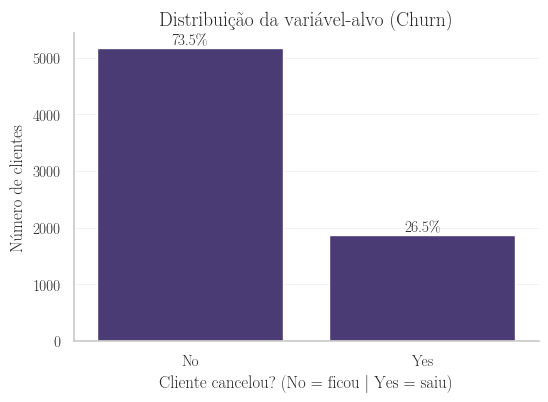

In [ ]:
# Distribuição da variável-alvo
contagem = df_raw["Churn"].value_counts()
percentual = df_raw["Churn"].value_counts(normalize=True) * 100
print(pd.DataFrame({"clientes": contagem, "%": percentual.round(1)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_raw, x="Churn", order=["No", "Yes"], ax=ax)
for barra, categoria in zip(ax.patches, ["No", "Yes"]):
    ax.annotate(f"{percentual[categoria]:.1f}%", (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                ha="center", va="bottom", fontsize=11)
ax.set_title("Distribuição da variável-alvo (Churn)")
ax.set_xlabel("Cliente cancelou? (No = ficou | Yes = saiu)")
ax.set_ylabel("Número de clientes")
plt.show()

**Interpretação.** A base tem 7.043 clientes, dos quais 1.869 (**26,5%**) cancelaram e 5.174 (73,5%) permaneceram: há desbalanceamento moderado. Isso confirma a escolha da ROC-AUC (e de métricas auxiliares como recall e PR-AUC) em vez de apenas acurácia, e justifica a **estratificação** nas separações de dados.

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

**Resposta do aluno — Exercício 2**

Plano: (1) diagnosticar a qualidade dos dados, (2) tratar o que for necessário, (3) explorar visualmente $\mathbf{X}$ e $\mathbf{y}$ e (4) conferir a base final.

In [ ]:
# 2.1 Diagnóstico de qualidade
print("=== Tipos de dados ===")
print(df_raw.dtypes.to_string())

print("\n=== Valores ausentes (NaN) por coluna ===")
print(df_raw.isna().sum().to_string())

print("\n=== Duplicidades ===")
print("Linhas totalmente duplicadas:", df_raw.duplicated().sum())
print("customerID repetidos:", df_raw["customerID"].duplicated().sum())
print("Linhas iguais se ignorarmos o customerID:", df_raw.drop(columns="customerID").duplicated().sum())

=== Tipos de dados ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

=== Valores ausentes (NaN) por coluna ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract        

In [ ]:
# Categorias: procurando inconsistências (grafias diferentes, espaços, etc.)
cols_texto = [c for c in df_raw.select_dtypes(exclude="number").columns if c not in ("customerID", "TotalCharges")]
for c in cols_texto:
    print(f"{c:18s} -> {sorted(df_raw[c].unique().tolist())}")

print("\nEspaços sobrando no início/fim dos textos?",
      any((df_raw[c] != df_raw[c].str.strip()).any() for c in cols_texto))

gender             -> ['Female', 'Male']
Partner            -> ['No', 'Yes']
Dependents         -> ['No', 'Yes']
PhoneService       -> ['No', 'Yes']
MultipleLines      -> ['No', 'No phone service', 'Yes']
InternetService    -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity     -> ['No', 'No internet service', 'Yes']
OnlineBackup       -> ['No', 'No internet service', 'Yes']
DeviceProtection   -> ['No', 'No internet service', 'Yes']
TechSupport        -> ['No', 'No internet service', 'Yes']
StreamingTV        -> ['No', 'No internet service', 'Yes']
StreamingMovies    -> ['No', 'No internet service', 'Yes']
Contract           -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   -> ['No', 'Yes']
PaymentMethod      -> ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn              -> ['No', 'Yes']

Espaços sobrando no início/fim dos textos? False


In [ ]:
# TotalCharges está como texto (object/str) mas deveria ser número. Por quê?
convertido = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
print("Valores que não viram número:", convertido.isna().sum())

problematicas = df_raw.loc[convertido.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
print("\nValor original dessas células:", problematicas["TotalCharges"].unique())
problematicas

Valores que não viram número: 11

Valor original dessas células: <ArrowStringArray>
[' ']
Length: 1, dtype: str


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


        tenure  MonthlyCharges
count  7043.00         7043.00
mean     32.37           64.76
std      24.56           30.09
min       0.00           18.25
25%       9.00           35.50
50%      29.00           70.35
75%      55.00           89.85
max      72.00          118.75

tenure negativo: 0 | MonthlyCharges <= 0: 0
Clientes com tenure = 0: 11


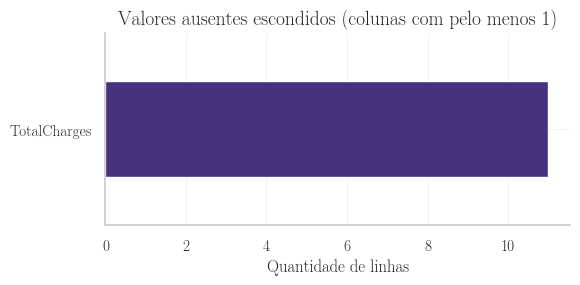

In [ ]:
# Valores impossíveis? (negativos, zeros estranhos)
print(df_raw[["tenure", "MonthlyCharges"]].describe().round(2))
print("\ntenure negativo:", (df_raw["tenure"] < 0).sum(),
      "| MonthlyCharges <= 0:", (df_raw["MonthlyCharges"] <= 0).sum())
print("Clientes com tenure = 0:", (df_raw["tenure"] == 0).sum())

# Gráfico de valores ausentes (após converter TotalCharges para número)
ausentes = df_raw.assign(TotalCharges=convertido).isna().sum()
ausentes = ausentes[ausentes > 0]
fig, ax = plt.subplots(figsize=(6, 2.5))
ausentes.plot(kind="barh", ax=ax)
ax.set_title("Valores ausentes escondidos (colunas com pelo menos 1)")
ax.set_xlabel("Quantidade de linhas")
plt.show()

**Achados do diagnóstico**

| Item | Resultado |
|---|---|
| Tipos de dados | `TotalCharges` veio como **texto**, mas deveria ser numérica. As demais colunas têm o tipo esperado. |
| Valores ausentes | Nenhum `NaN` na leitura, **mas** 11 células de `TotalCharges` contêm apenas um espaço em branco (ausência "escondida"). |
| Duplicidades | 0 linhas totalmente duplicadas e 0 `customerID` repetidos. Há 22 linhas iguais se ignorarmos o ID: são clientes diferentes com o mesmo perfil. |
| Categorias | Sem grafias inconsistentes nem espaços extras. As categorias "No internet service" e "No phone service" são consistentes (o cliente não tem aquele serviço). |
| Valores impossíveis | Nenhum `tenure` negativo nem `MonthlyCharges` ≤ 0. |
| Causa dos 11 vazios | Todos têm `tenure` = 0: são clientes que acabaram de entrar e ainda não receberam fatura. |

In [ ]:
# 2.2 Data wrangling: cada passo está comentado com o motivo
df = df_raw.copy()

# (a) TotalCharges: texto -> número. As 11 células vazias viram NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# (b) Esses NaN são clientes com tenure = 0 (acabaram de entrar, ainda não receberam fatura).
#     Regra de negócio: ainda não foi cobrado nada => TotalCharges = 0.
#     Não usamos média/mediana: seria inventar um valor que não faz sentido.
sem_fatura = df["TotalCharges"].isna() & (df["tenure"] == 0)
print("NaN explicados por tenure = 0:", sem_fatura.sum(), "de", df["TotalCharges"].isna().sum())
df.loc[sem_fatura, "TotalCharges"] = 0.0

# (c) Remove espaços sobrando nos textos (não havia, mas deixa o processo seguro)
for c in cols_texto:
    df[c] = df[c].str.strip()

# (d) Alvo: Yes/No -> 1/0 (formato numérico exigido pelas métricas)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# (e) NÃO removemos linhas "duplicadas ignorando o ID": são clientes diferentes com
#     o mesmo perfil (ex.: contrato mensal, mesmos serviços). Isso é normal em dados de cadastro.
print("TotalCharges agora é:", df["TotalCharges"].dtype, "| NaN restantes:", df["TotalCharges"].isna().sum())

NaN explicados por tenure = 0: 11 de 11
TotalCharges agora é: float64 | NaN restantes: 0


**Decisões de tratamento (e por quê)**

| Alteração | Motivo |
|---|---|
| `TotalCharges`: texto → número | Variável é um valor monetário; modelos precisam de número. |
| 11 vazios → `0,0` (todos com `tenure` = 0) | Regra de negócio: sem fatura emitida, o total cobrado é zero. Preencher com média inventaria um valor sem sentido. Como a regra não "aprende" nada dos dados, não há risco de vazamento. |
| `Churn`: Yes/No → 1/0 | Formato numérico exigido pelas métricas. |
| Espaços nos textos | Verificação de segurança (não havia espaços sobrando). |
| **Não** removemos as 22 linhas "iguais sem o ID" | São clientes distintos com o mesmo perfil, algo normal em cadastro; removê-las seria perder informação sem justificativa. |
| **Nenhuma** linha ou coluna removida para "melhorar a métrica" | Conforme as orientações do enunciado. |

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8


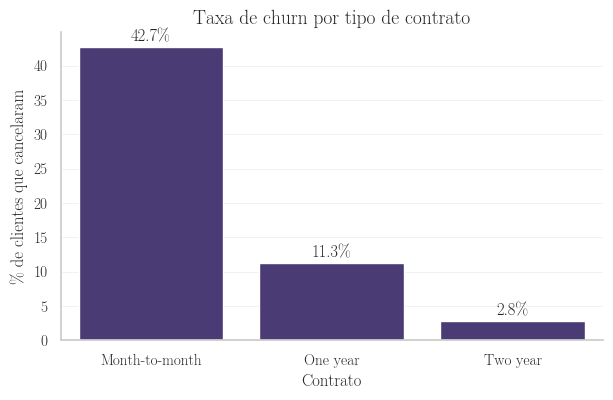

In [ ]:
# 2.3 Análise exploratória — Gráfico 1: churn por tipo de contrato
taxa_contrato = df.groupby("Contract")["Churn"].mean().mul(100).sort_values(ascending=False)
print(taxa_contrato.round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=taxa_contrato.index, y=taxa_contrato.values, ax=ax)
for i, v in enumerate(taxa_contrato.values):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center")
ax.set_title("Taxa de churn por tipo de contrato")
ax.set_xlabel("Contrato")
ax.set_ylabel("% de clientes que cancelaram")
plt.show()

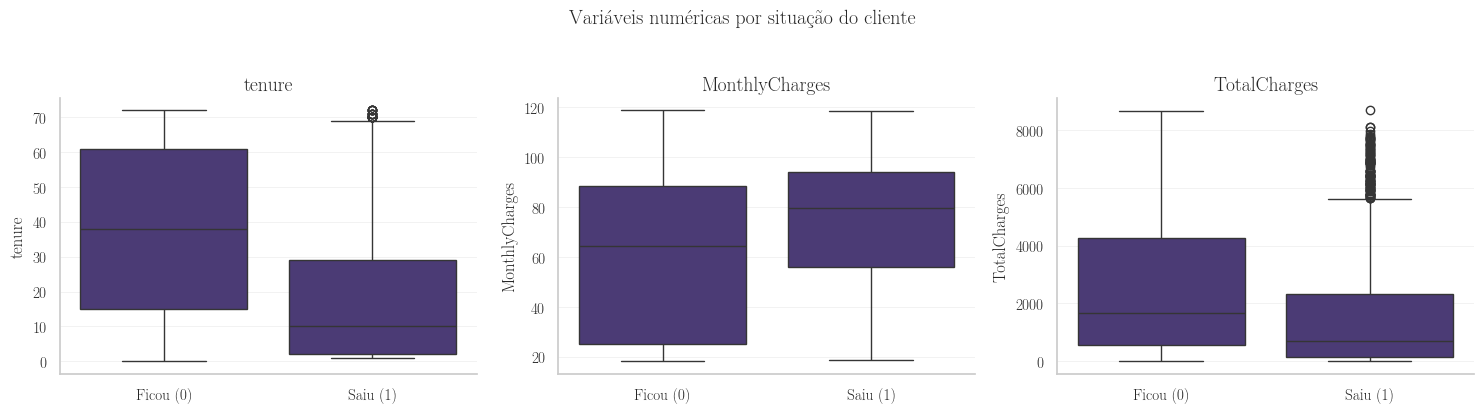

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0        38.0            64.4        1679.5
1        10.0            79.6         703.6


In [ ]:
# Gráfico 2: variáveis numéricas x churn (boxplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_xticks([0, 1], ["Ficou (0)", "Saiu (1)"])
    ax.set_xlabel("")
    ax.set_title(col)
plt.suptitle("Variáveis numéricas por situação do cliente", y=1.03)
plt.tight_layout()
plt.show()

print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].median().round(1))

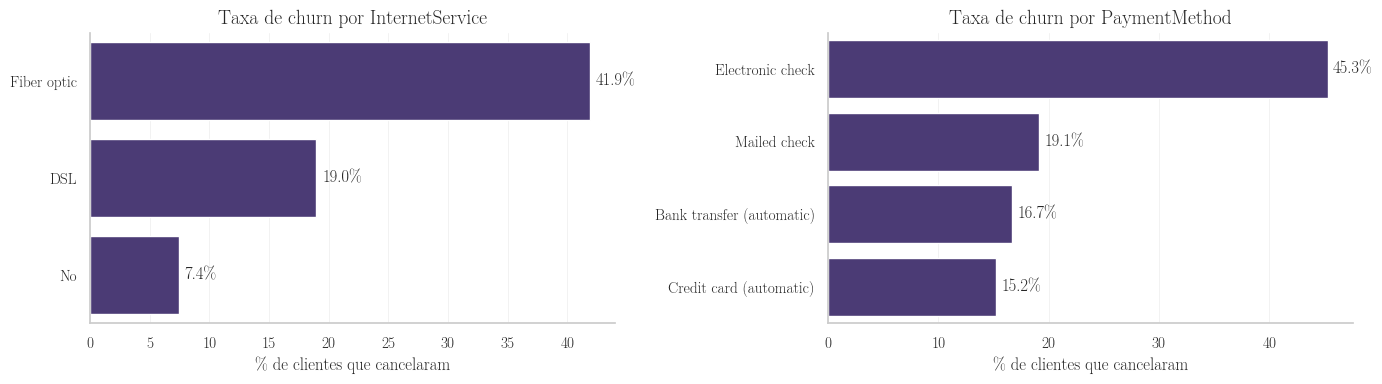

In [ ]:
# Gráfico 3: churn por tipo de internet e por forma de pagamento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["InternetService", "PaymentMethod"]):
    taxa = df.groupby(col)["Churn"].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=taxa.values, y=taxa.index, ax=ax)
    for i, v in enumerate(taxa.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
    ax.set_title(f"Taxa de churn por {col}")
    ax.set_xlabel("% de clientes que cancelaram")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

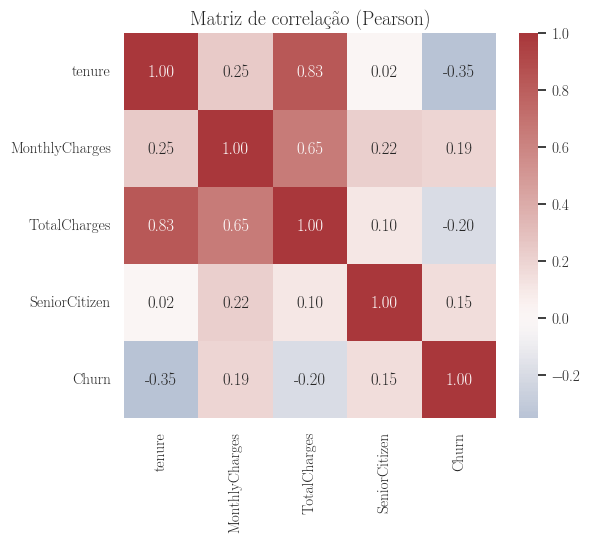

In [ ]:
# Gráfico 4: correlação entre as variáveis numéricas e o alvo
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.show()

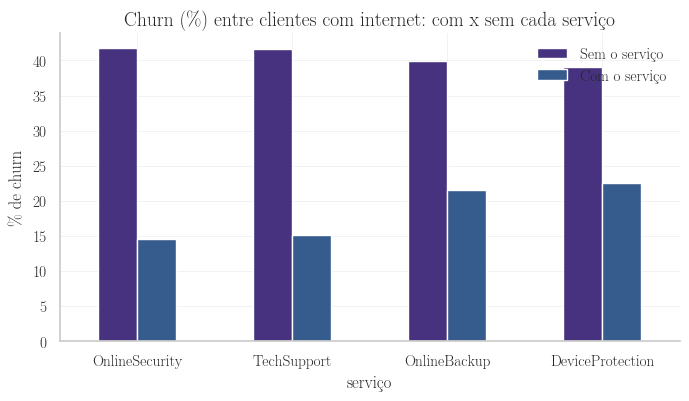

                  Sem o serviço  Com o serviço
serviço                                       
OnlineSecurity             41.8           14.6
TechSupport                41.6           15.2
OnlineBackup               39.9           21.5
DeviceProtection           39.1           22.5


In [ ]:
# Gráfico 5: o efeito de serviços de proteção/suporte (variáveis "extras")
servicos = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]
linhas = []
for s in servicos:
    sub = df[df["InternetService"] != "No"]            # só quem tem internet
    taxa = sub.groupby(s)["Churn"].mean().mul(100)
    linhas.append({"serviço": s, "Sem o serviço": taxa["No"], "Com o serviço": taxa["Yes"]})
tabela_serv = pd.DataFrame(linhas).set_index("serviço")
tabela_serv.plot(kind="bar", figsize=(8, 4), rot=0)
plt.title("Churn (%) entre clientes com internet: com x sem cada serviço")
plt.ylabel("% de churn")
plt.show()
print(tabela_serv.round(1))

**Interpretação da análise exploratória**

- **Contrato é o fator mais marcante:** clientes de contrato mensal cancelam **42,7%**, contra 11,3% (1 ano) e apenas 2,8% (2 anos). Quem tem compromisso mais longo tende a ficar.
- **Tempo de casa:** quem saiu tem mediana de **10 meses** de `tenure`, contra 38 meses de quem ficou. O churn se concentra nos primeiros meses (correlação com o alvo: −0,35, a mais forte entre as numéricas). `TotalCharges` tem correlação −0,20, em grande parte por ser "tempo × mensalidade".
- **Valor mensal:** quem saiu paga mais por mês (mediana US$ 79,6 contra US$ 64,4; correlação +0,19). Isso conversa com a internet em fibra óptica.
- **Internet e pagamento:** fibra óptica tem churn de ~41,9% (DSL ~19,0%; sem internet ~7,4%). Pagamento por *Electronic check* tem ~45,3% de churn, contra 15–19% nas demais formas.
- **Serviços de proteção/suporte:** entre quem tem internet, quem tem segurança online ou suporte técnico cancela bem menos (~15%) do que quem não tem (~42%).
- **Para a modelagem:** variáveis de contrato, tempo, internet e serviços devem ser importantes; há variáveis correlacionadas entre si (ex.: `tenure`, `MonthlyCharges` e `TotalCharges`), o que não é problema para modelos de árvores.

> Observação: os gráficos mostram **associação**, não causa (ex.: o contrato mensal não "causa" o churn sozinho).

In [ ]:
# 2.4 Base final após o tratamento
print("Dimensões após o tratamento:", df.shape)
print("Valores ausentes no total:", int(df.isna().sum().sum()))
print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("customerID repetidos:", df["customerID"].duplicated().sum())
print("Tipos:", df.dtypes.value_counts().to_dict())
df.head()

Dimensões após o tratamento: (7043, 21)
Valores ausentes no total: 0
Linhas totalmente duplicadas: 0
customerID repetidos: 0
Tipos: {<StringDtype(na_value=nan)>: 16, dtype('int64'): 3, dtype('float64'): 2}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Base final.** Após o tratamento a base continua com **7.043 linhas × 21 colunas**, sem valores ausentes e sem linhas duplicadas.

**Decisões que ficam para o pipeline de modelagem** (aprendem parâmetros dos dados, então só podem usar o treino de cada fold): imputação de segurança (mediana para numéricas e moda para categóricas) e codificação *one-hot* das variáveis categóricas. Não aplicamos padronização (*scaling*) porque Random Forest, XGBoost e LightGBM não são sensíveis à escala das variáveis.

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

**Resposta do aluno — Exercício 3**

Esta etapa define **antes de treinar** o que entra no modelo, como os dados serão divididos e como vamos medir.

In [ ]:
# 3.1 Definição de X e y
# customerID é só um código: não generaliza (o ID de um cliente novo nunca foi visto) e
# pode "decorar" clientes no treino. Por isso sai de X.
COLUNAS_REMOVIDAS = ["customerID"]

X = df.drop(columns=COLUNAS_REMOVIDAS + ["Churn"])
y = df["Churn"]

# Colunas por tipo (usadas no pré-processamento)
cols_num = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cols_cat = [c for c in X.columns if c not in cols_num]
print("X:", X.shape, "| y:", y.shape)
print("Numéricas/binárias:", cols_num)
print("Categóricas (", len(cols_cat), "):", cols_cat)

X: (7043, 19) | y: (7043,)
Numéricas/binárias: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas ( 15 ): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# 3.2 Separação treino x teste (80% / 20%), estratificada e com semente fixa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("% de churn no treino:", round(y_train.mean() * 100, 2), "| no teste:", round(y_test.mean() * 100, 2))

# Validação cruzada (dentro do treino): 5 folds estratificados.
# O MESMO objeto cv será usado nos 3 modelos => os mesmos folds para todos.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# A partir daqui o X_test e o y_test NÃO podem ser usados até o Exercício 7.

Treino: (5634, 19) | Teste: (1409, 19)
% de churn no treino: 26.54 | no teste: 26.54


In [ ]:
# 3.3 Métricas
METRICA_PRINCIPAL = "roc_auc"
METRICAS = {
    "roc_auc": "roc_auc",                      # principal
    "pr_auc": "average_precision",             # auxiliar (área sob Precision x Recall)
    "f1": "f1",                                # auxiliar
    "recall": "recall",                        # auxiliar
    "precision": "precision",                  # auxiliar
    "accuracy": "accuracy",                    # auxiliar (só para referência)
}
print("Métrica principal:", METRICA_PRINCIPAL)
print("Auxiliares:", [m for m in METRICAS if m != "roc_auc"])

# Pré-processamento (idêntico para os 3 modelos). Fica DENTRO do Pipeline,
# então é "aprendido" só com os dados de treino de cada fold (sem vazamento).
def criar_preprocessador():
    numerico = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([("num", numerico, cols_num), ("cat", categorico, cols_cat)])

def montar_pipeline(modelo):
    """Junta pré-processamento + modelo em um único objeto."""
    return Pipeline([("prep", criar_preprocessador()), ("modelo", modelo)])

# Hiperparâmetros fixos (não entram no tuning) e hiperparâmetros do baseline
def construir_modelo(nome, params=None):
    params = params or {}
    if nome == "Random Forest":
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    if nome == "XGBoost":
        return XGBClassifier(random_state=SEED, eval_metric="logloss", verbosity=0, n_jobs=-1, **params)
    if nome == "LightGBM":
        return LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, **params)
    raise ValueError(nome)

NOMES = ["Random Forest", "XGBoost", "LightGBM"]
PARAMS_BASE = {
    "Random Forest": {"n_estimators": 200},
    "XGBoost":       {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 6},
    "LightGBM":      {"n_estimators": 200, "learning_rate": 0.1, "num_leaves": 31},
}

Métrica principal: roc_auc
Auxiliares: ['pr_auc', 'f1', 'recall', 'precision', 'accuracy']


**Justificativas**

**Variáveis (3.1).** $\mathbf{X}$ tem 19 variáveis e $\mathbf{y}$ é `Churn`.
- **Removida:** `customerID` — identificador sem valor preditivo e que permitiria ao modelo "decorar" clientes (risco de *data leakage*/sobreajuste).
- **Análise de vazamento:** nenhuma variável restante revela diretamente o alvo; todas descrevem perfil, serviços, contrato e cobrança. `TotalCharges` é aproximadamente `tenure × MonthlyCharges` (redundância parcial, mas não vazamento: é conhecida antes do cancelamento).
- **Limitação a registrar:** a base é uma "foto" e, para quem já saiu, `tenure` e `TotalCharges` refletem o tempo até a saída. Em produção, esses valores seriam do cliente ainda ativo. Isso pode deixar o desempenho um pouco otimista e deve ser considerado ao interpretar os resultados.

**Divisão (3.2).** 80% treino (5.634 clientes) e 20% teste (1.409), com `random_state=42` e **estratificação** (26,54% de churn nos dois conjuntos). Validação cruzada **estratificada de 5 folds** (`shuffle=True`, `random_state=42`) dentro do treino — o mesmo objeto `cv` é reutilizado nos três modelos, garantindo os mesmos folds.

**Métricas (3.3).**
- **ROC-AUC (principal):** 0,5 = chute; 1,0 = ordenação perfeita. Não depende de limiar e é robusta ao desbalanceamento.
- **PR-AUC:** foca na classe minoritária (referência de "chute" ≈ 0,265, a taxa de churn).
- **Recall:** dos clientes que cancelaram, quantos o modelo encontrou. **Precision:** dos que o modelo apontou como churn, quantos realmente cancelaram. **F1:** equilíbrio entre os dois. Todos com limiar 0,5.
- **Acurácia:** só referência (a classe majoritária sozinha dá ~73,5%).

**Comparabilidade.** O pré-processamento é idêntico para os três modelos (mesmo `Pipeline`, mesma codificação *one-hot*), então não há diferença de pipeline entre algoritmos a justificar.

<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

**Resposta do aluno — Exercício 4**

Os três baselines usam hiperparâmetros "razoáveis" fixados antes do tuning (listados na saída abaixo), o mesmo pipeline de pré-processamento, os mesmos folds e as mesmas métricas.

In [ ]:
# Função que avalia QUALQUER pipeline com o mesmo protocolo (reutilizada em todo o notebook)
def avaliar_cv(pipe):
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=METRICAS, return_train_score=True)
    return {
        "auc_treino": r["train_roc_auc"].mean(),
        "auc_cv": r["test_roc_auc"].mean(),
        "auc_cv_std": r["test_roc_auc"].std(),
        "gap": r["train_roc_auc"].mean() - r["test_roc_auc"].mean(),
        "pr_auc_cv": r["test_pr_auc"].mean(),
        "f1_cv": r["test_f1"].mean(),
        "recall_cv": r["test_recall"].mean(),
        "precision_cv": r["test_precision"].mean(),
        "acc_cv": r["test_accuracy"].mean(),
        "tempo_fit_s": r["fit_time"].mean(),
    }

# 4.1 a 4.3: treina os três baselines com o mesmo protocolo
linhas = []
for nome in NOMES:
    print(f"Hiperparâmetros baseline {nome}: {PARAMS_BASE[nome]}")
    res = avaliar_cv(montar_pipeline(construir_modelo(nome, PARAMS_BASE[nome])))
    linhas.append({"modelo": nome, **res})

tab_baseline = pd.DataFrame(linhas).set_index("modelo")
tab_baseline.round(4)

Hiperparâmetros baseline Random Forest: {'n_estimators': 200}


Hiperparâmetros baseline XGBoost: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 6}


Hiperparâmetros baseline LightGBM: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31}


,auc_treino,auc_cv,auc_cv_std,gap,pr_auc_cv,f1_cv,recall_cv,precision_cv,acc_cv,tempo_fit_s
modelo,,,,,,,,,,
Random Forest,0.9999,0.8199,0.0125,0.1801,0.6135,0.5372,0.4736,0.6216,0.7836,0.7883
XGBoost,0.9757,0.8347,0.0082,0.1410,0.6435,0.5705,0.5177,0.6360,0.7932,0.1823
LightGBM,0.9888,0.8308,0.0068,0.1579,0.6306,0.5719,0.5217,0.6336,0.7929,0.1554


,AUC treino,AUC CV (média),AUC CV (desvio),Gap (treino-CV),Tempo/fold (s)
modelo,,,,,
Random Forest,0.9999,0.8199,0.0125,0.1801,0.7883
XGBoost,0.9757,0.8347,0.0082,0.1410,0.1823
LightGBM,0.9888,0.8308,0.0068,0.1579,0.1554


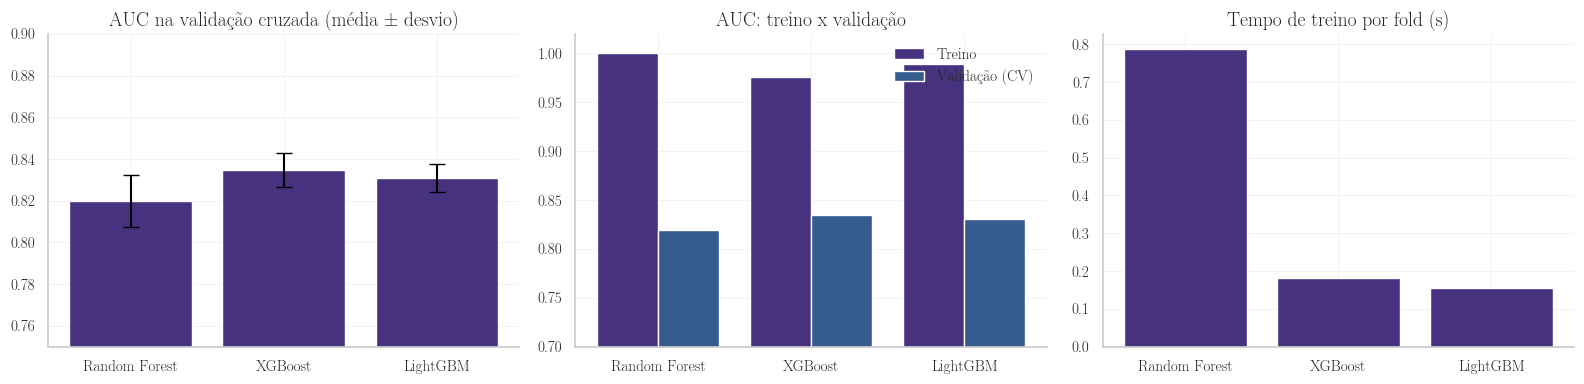

In [ ]:
# 4.4 Tabela única de comparação (exigida no enunciado)
tabela_ex4 = tab_baseline[["auc_treino", "auc_cv", "auc_cv_std", "gap", "tempo_fit_s"]].rename(columns={
    "auc_treino": "AUC treino", "auc_cv": "AUC CV (média)", "auc_cv_std": "AUC CV (desvio)",
    "gap": "Gap (treino-CV)", "tempo_fit_s": "Tempo/fold (s)"})
display(tabela_ex4.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# (a) média e dispersão do CV
axes[0].bar(NOMES, tab_baseline["auc_cv"], yerr=tab_baseline["auc_cv_std"], capsize=6)
axes[0].set_ylim(0.75, 0.9); axes[0].set_title("AUC na validação cruzada (média ± desvio)")
# (b) treino x validação
posicao = np.arange(3)
axes[1].bar(posicao - 0.2, tab_baseline["auc_treino"], 0.4, label="Treino")
axes[1].bar(posicao + 0.2, tab_baseline["auc_cv"], 0.4, label="Validação (CV)")
axes[1].set_xticks(posicao, NOMES); axes[1].set_ylim(0.7, 1.02)
axes[1].set_title("AUC: treino x validação"); axes[1].legend()
# (c) tempo
axes[2].bar(NOMES, tab_baseline["tempo_fit_s"])
axes[2].set_title("Tempo de treino por fold (s)")
plt.tight_layout(); plt.show()

**Interpretação do baseline**

- **Overfitting claro nos três modelos.** A AUC no treino é altíssima (Random Forest ≈ 1,000; LightGBM ≈ 0,989; XGBoost ≈ 0,976), enquanto na validação cai para 0,82–0,83. Os gaps (treino − CV) são grandes: **0,18 (RF), 0,16 (LGBM) e 0,14 (XGB)**. O modelo está "decorando" o treino.
- **Não há underfitting:** a AUC de validação (≈ 0,82–0,83) é bem superior a 0,5 e o treino é quase perfeito.
- **Comparação:** XGBoost (0,835) e LightGBM (0,831) saem na frente do Random Forest (0,820) já no baseline, e são mais rápidos (~0,2 s por fold contra ~0,8 s). As diferenças entre os modelos (≈ 0,01) são do tamanho do desvio-padrão entre folds (0,007–0,013), então ainda não dá para declarar um vencedor.
- **O que esperar do tuning:** reduzir a complexidade (árvores mais rasas, mais regularização) deve diminuir o gap.

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

**Resposta do aluno — Exercício 5**

Todo o tuning usa **apenas o treino**, com a mesma métrica (ROC-AUC) e os mesmos 5 folds.

**Espaços de busca**

| Modelo | Grid Search (12 combinações × 5 folds = 60 treinos) | Optuna (25 trials × 5 folds) |
|---|---|---|
| Random Forest | `n_estimators` {200, 400} · `max_depth` {5, 8, 12} · `min_samples_leaf` {5, 15} | `n_estimators` 100–500 · `max_depth` 3–15 · `min_samples_leaf` 1–30 · `max_features` {sqrt, log2} |
| XGBoost | `n_estimators` {100, 300} · `learning_rate` {0,03; 0,1} · `max_depth` {2, 3, 5} | `n_estimators` 100–500 · `learning_rate` 0,01–0,3 (log) · `max_depth` 2–8 · `subsample` · `colsample_bytree` · `min_child_weight` · `reg_lambda` |
| LightGBM | `n_estimators` {100, 300} · `learning_rate` {0,03; 0,1} · `num_leaves` {7, 15, 31} | `n_estimators` 100–500 · `learning_rate` 0,01–0,3 (log) · `num_leaves` 4–64 · `min_child_samples` · `subsample` · `colsample_bytree` · `reg_lambda` |

As grades exploram **complexidade** (profundidade/folhas), **número de árvores** e **taxa de aprendizado**. O Optuna usa 25 trials por modelo (≥ 20, como pede o enunciado), sampler TPE com semente 42.

In [ ]:
# 5.1 GRID SEARCH — uma grade por modelo (os nomes têm o prefixo "modelo__" por causa do Pipeline)
GRADES = {
    "Random Forest": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [5, 8, 12],
        "modelo__min_samples_leaf": [5, 15],
    },
    "XGBoost": {
        "modelo__n_estimators": [100, 300],
        "modelo__learning_rate": [0.03, 0.1],
        "modelo__max_depth": [2, 3, 5],
    },
    "LightGBM": {
        "modelo__n_estimators": [100, 300],
        "modelo__learning_rate": [0.03, 0.1],
        "modelo__num_leaves": [7, 15, 31],
    },
}

resultados_grid = {}      # guarda tudo de cada busca
for nome in NOMES:
    busca = GridSearchCV(
        montar_pipeline(construir_modelo(nome, PARAMS_BASE[nome])),
        param_grid=GRADES[nome], scoring=METRICA_PRINCIPAL, cv=cv,
        return_train_score=True, refit=False, n_jobs=None,
    )
    t0 = time.time()
    busca.fit(X_train, y_train)
    tempo = time.time() - t0

    cvr = pd.DataFrame(busca.cv_results_)
    melhor = cvr.loc[cvr["rank_test_score"].idxmin()]
    params = {k.replace("modelo__", ""): v for k, v in melhor["params"].items()}
    resultados_grid[nome] = {"cv_results": cvr, "params": params, "score": melhor["mean_test_score"],
                             "std": melhor["std_test_score"], "tempo": tempo,
                             "n_fits": len(cvr) * cv.get_n_splits(), "n_comb": len(cvr)}
    print(f"{nome:14s} | {len(cvr):2d} combinações | melhor AUC CV = {melhor['mean_test_score']:.4f} | {tempo:6.1f}s | {params}")

Random Forest  | 12 combinações | melhor AUC CV = 0.8484 |   56.4s | {'max_depth': 8, 'min_samples_leaf': 15, 'n_estimators': 400}


XGBoost        | 12 combinações | melhor AUC CV = 0.8500 |   10.9s | {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}


LightGBM       | 12 combinações | melhor AUC CV = 0.8487 |   12.9s | {'learning_rate': 0.03, 'n_estimators': 300, 'num_leaves': 7}


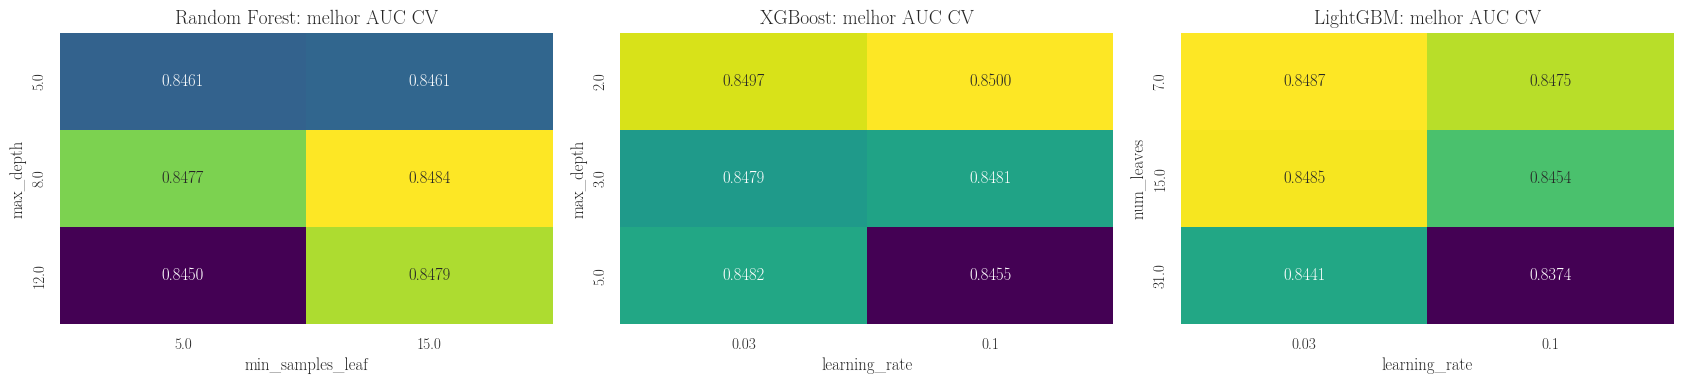

In [ ]:
# Mapa de calor do Grid Search: dois hiperparâmetros principais por modelo
pares = {
    "Random Forest": ("param_modelo__max_depth", "param_modelo__min_samples_leaf"),
    "XGBoost":       ("param_modelo__max_depth", "param_modelo__learning_rate"),
    "LightGBM":      ("param_modelo__num_leaves", "param_modelo__learning_rate"),
}
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, nome in zip(axes, NOMES):
    linha, coluna = pares[nome]
    cvr = resultados_grid[nome]["cv_results"].copy()
    cvr[linha] = cvr[linha].astype(float); cvr[coluna] = cvr[coluna].astype(float)
    mapa = cvr.pivot_table(index=linha, columns=coluna, values="mean_test_score", aggfunc="max")
    sns.heatmap(mapa, annot=True, fmt=".4f", cmap="viridis", ax=ax, cbar=False)
    ax.set_title(f"{nome}: melhor AUC CV")
    ax.set_ylabel(linha.replace("param_modelo__", "")); ax.set_xlabel(coluna.replace("param_modelo__", ""))
plt.tight_layout(); plt.show()

In [ ]:
# 5.2 OPTUNA — espaço de busca de cada modelo (a busca é "inteligente": aprende com os trials anteriores)
N_TRIALS = 25

def espaco_busca(nome, trial):
    if nome == "Random Forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 15),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        }
    if nome == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        }
    if nome == "LightGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 4, 64),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "subsample_freq": 1,                      # necessário para o subsample valer no LightGBM
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        }

def criar_objetivo(nome):
    """Função objetivo: devolve a AUC média do MESMO cv (5 folds) no treino."""
    def objetivo(trial):
        params = espaco_busca(nome, trial)
        pipe = montar_pipeline(construir_modelo(nome, params))
        return cross_val_score(pipe, X_train, y_train, cv=cv, scoring=METRICA_PRINCIPAL).mean()
    return objetivo

resultados_optuna = {}
for nome in NOMES:
    estudo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = time.time()
    estudo.optimize(criar_objetivo(nome), n_trials=N_TRIALS)
    tempo = time.time() - t0
    resultados_optuna[nome] = {"study": estudo, "params": estudo.best_params, "score": estudo.best_value, "tempo": tempo}
    print(f"{nome:14s} | {N_TRIALS} trials | melhor AUC CV = {estudo.best_value:.4f} | {tempo:6.1f}s")
    print("   melhores parâmetros:", estudo.best_params)

Random Forest  | 25 trials | melhor AUC CV = 0.8480 |  111.2s
   melhores parâmetros: {'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 20, 'max_features': 'sqrt'}


XGBoost        | 25 trials | melhor AUC CV = 0.8507 |   30.2s
   melhores parâmetros: {'n_estimators': 450, 'learning_rate': 0.011690920245940366, 'max_depth': 3, 'subsample': 0.8809757217274072, 'colsample_bytree': 0.6060739955794969, 'min_child_weight': 5, 'reg_lambda': 1.0599663443186522}


LightGBM       | 25 trials | melhor AUC CV = 0.8498 |   27.7s
   melhores parâmetros: {'n_estimators': 200, 'learning_rate': 0.01878617020502337, 'num_leaves': 19, 'min_child_samples': 45, 'subsample': 0.613804252971933, 'colsample_bytree': 0.6412985044225146, 'reg_lambda': 0.610753789873027}


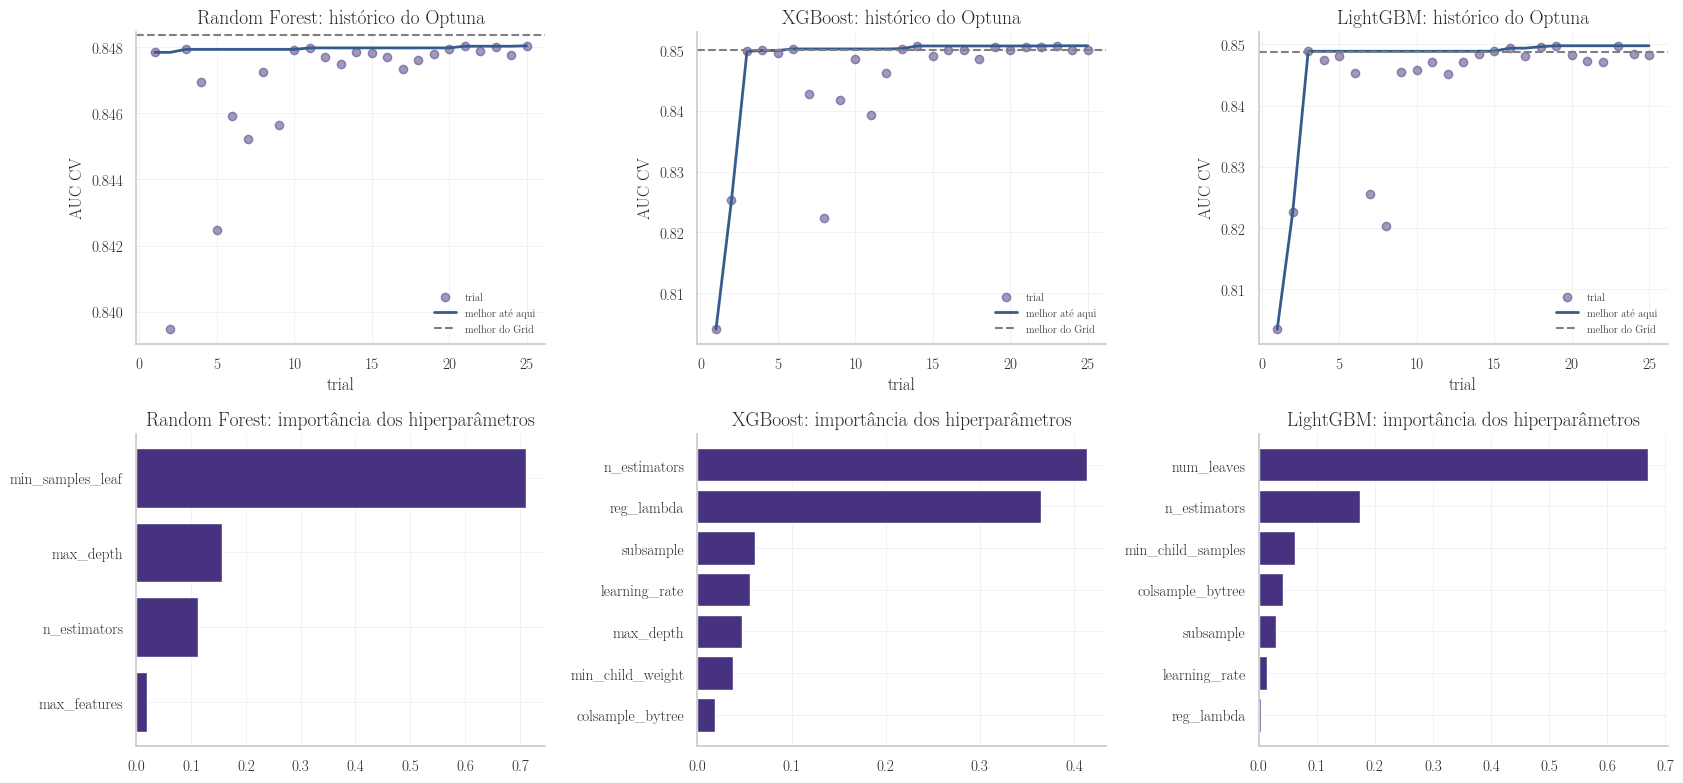

In [ ]:
# Para o LightGBM o Optuna fixou subsample_freq=1 (não é "sugerido"): garantimos que ele conste nos parâmetros finais
resultados_optuna["LightGBM"]["params"] = {**resultados_optuna["LightGBM"]["params"], "subsample_freq": 1}

# Histórico de otimização (melhor valor até o trial) e importância dos hiperparâmetros
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for j, nome in enumerate(NOMES):
    est = resultados_optuna[nome]["study"]
    valores = [t.value for t in est.trials]
    axes[0, j].plot(range(1, len(valores) + 1), valores, "o", alpha=0.5, label="trial")
    axes[0, j].plot(range(1, len(valores) + 1), np.maximum.accumulate(valores), "-", lw=2, label="melhor até aqui")
    axes[0, j].axhline(resultados_grid[nome]["score"], color="gray", ls="--", label="melhor do Grid")
    axes[0, j].set_title(f"{nome}: histórico do Optuna"); axes[0, j].set_xlabel("trial"); axes[0, j].set_ylabel("AUC CV")
    axes[0, j].legend(fontsize=8)

    imp = optuna.importance.get_param_importances(est)
    axes[1, j].barh(list(imp.keys())[::-1], list(imp.values())[::-1])
    axes[1, j].set_title(f"{nome}: importância dos hiperparâmetros")
plt.tight_layout(); plt.show()

,AUC Grid,AUC Optuna,tempo Grid (s),tempo Optuna (s),avaliações Grid,avaliações Optuna,pior config Grid,pior trial Optuna,% trials Optuna >= melhor Grid
modelo,,,,,,,,,
Random Forest,0.8484,0.8480,56.4493,111.1792,12,25,0.8450,0.8395,0.0
XGBoost,0.8500,0.8507,10.8534,30.2322,12,25,0.8334,0.8040,44.0
LightGBM,0.8487,0.8498,12.8972,27.6994,12,25,0.8255,0.8035,24.0


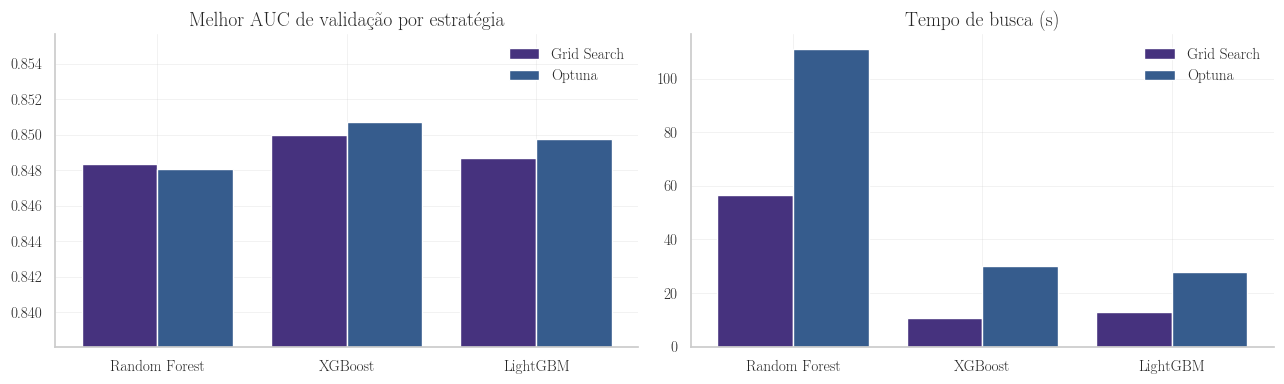

In [ ]:
# 5.3 Comparação Grid Search x Optuna
linhas = []
for nome in NOMES:
    g, o = resultados_grid[nome], resultados_optuna[nome]
    valores_o = np.array([t.value for t in o["study"].trials])
    valores_g = g["cv_results"]["mean_test_score"].values
    linhas.append({
        "modelo": nome,
        "AUC Grid": g["score"], "AUC Optuna": o["score"],
        "tempo Grid (s)": g["tempo"], "tempo Optuna (s)": o["tempo"],
        "avaliações Grid": g["n_comb"], "avaliações Optuna": N_TRIALS,
        "pior config Grid": valores_g.min(), "pior trial Optuna": valores_o.min(),
        "% trials Optuna >= melhor Grid": (valores_o >= g["score"]).mean() * 100,
    })
comparacao = pd.DataFrame(linhas).set_index("modelo")
display(comparacao.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(3)
axes[0].bar(x - 0.2, comparacao["AUC Grid"], 0.4, label="Grid Search")
axes[0].bar(x + 0.2, comparacao["AUC Optuna"], 0.4, label="Optuna")
axes[0].set_xticks(x, NOMES); axes[0].set_ylim(comparacao[["AUC Grid", "AUC Optuna"]].min().min() - 0.01,
                                               comparacao[["AUC Grid", "AUC Optuna"]].max().max() + 0.005)
axes[0].set_title("Melhor AUC de validação por estratégia"); axes[0].legend()
axes[1].bar(x - 0.2, comparacao["tempo Grid (s)"], 0.4, label="Grid Search")
axes[1].bar(x + 0.2, comparacao["tempo Optuna (s)"], 0.4, label="Optuna")
axes[1].set_xticks(x, NOMES); axes[1].set_title("Tempo de busca (s)"); axes[1].legend()
plt.tight_layout(); plt.show()

**Resultados e comparação (Grid Search × Optuna)**

| Modelo | Melhor Grid (AUC CV) | Melhor Optuna (AUC CV) |
|---|---|---|
| Random Forest | 0,8484 (`max_depth`=8, `min_samples_leaf`=15, 400 árvores) | 0,8480 |
| XGBoost | 0,8500 (`learning_rate`=0,1, `max_depth`=2, 100 árvores) | 0,8507 (`learning_rate`≈0,012, `max_depth`=3, 450 árvores) |
| LightGBM | 0,8487 (`learning_rate`=0,03, 300 árvores, 7 folhas) | 0,8498 |

- **Qualidade:** as duas estratégias chegam a resultados **praticamente iguais** (diferença ≤ 0,0011), muito menor que o desvio-padrão entre folds (≈ 0,01). Não há vencedor estatístico. Em relação ao baseline, o ganho do tuning foi **grande** (AUC de ~0,82–0,83 para ~0,85).
- **Custo:** o Grid foi mais barato aqui (12 combinações) e o Optuna levou cerca de 2–3× mais tempo (25 trials, cada um com 5 treinos). O custo do Grid cresce rápido com o número de hiperparâmetros; o do Optuna é controlado pelo número de trials.
- **Comportamento da busca:** o Grid dá um mapa completo e fácil de explicar (mapas de calor acima), mas só olha os valores que listamos — o melhor XGBoost do Grid ficou **no canto da grade** (`max_depth`=2 e 100 árvores, os menores valores), sinal de que a grade poderia ser estendida nessa direção. O Optuna explora valores contínuos e mais hiperparâmetros (ex.: `subsample`, `reg_lambda`) e concentra os trials em regiões promissoras: 44% dos trials do XGBoost e 24% dos do LightGBM igualaram ou superaram o melhor do Grid. Para o Random Forest, nenhum trial superou o Grid. No histórico, o Optuna atinge o patamar de ~0,85 já nos primeiros trials e os demais só refinam: há um "platô" largo de configurações equivalentes. Pela importância dos hiperparâmetros, o que mais pesou foi o **controle de complexidade/regularização** e o **número de árvores**: `min_samples_leaf` no Random Forest, `n_estimators` e `reg_lambda` no XGBoost, `num_leaves` e `n_estimators` no LightGBM.
- **Estabilidade/ressalva:** ambas as buscas otimizam sobre os mesmos folds, então o melhor score tem um pequeno viés otimista; por isso a avaliação final no teste é essencial. Os resultados do Optuna dependem da semente; o Grid é determinístico.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

**Resposta do aluno — Exercício 6**

A escolha do modelo final usa **somente treino e validação cruzada** — o teste continua intocado.

In [ ]:
# 6.1 Tabela final com as 9 configurações (baseline, melhor Grid e melhor Optuna de cada algoritmo)
configuracoes = {}
for nome in NOMES:
    configuracoes[(nome, "Baseline")] = PARAMS_BASE[nome]
    configuracoes[(nome, "Grid Search")] = {**PARAMS_BASE[nome], **resultados_grid[nome]["params"]}
    configuracoes[(nome, "Optuna")] = {**PARAMS_BASE[nome], **resultados_optuna[nome]["params"]}

linhas = []
for (nome, estrategia), params in configuracoes.items():
    res = avaliar_cv(montar_pipeline(construir_modelo(nome, params)))
    linhas.append({"modelo": nome, "estratégia": estrategia, **res})

tab_final = pd.DataFrame(linhas)
tab_final["config"] = tab_final["modelo"] + " | " + tab_final["estratégia"]
tab_final = tab_final.set_index("config")
colunas_mostrar = ["auc_treino", "auc_cv", "auc_cv_std", "gap", "pr_auc_cv", "f1_cv", "recall_cv", "precision_cv", "acc_cv", "tempo_fit_s"]
tab_final[colunas_mostrar].sort_values("auc_cv", ascending=False).round(4)

,auc_treino,auc_cv,auc_cv_std,gap,pr_auc_cv,f1_cv,recall_cv,precision_cv,acc_cv,tempo_fit_s
config,,,,,,,,,,
XGBoost | Optuna,0.8684,0.8507,0.0113,0.0178,0.6714,0.5871,0.5184,0.6777,0.8065,0.2425
XGBoost | Grid Search,0.8642,0.8500,0.0116,0.0143,0.6700,0.5885,0.5258,0.6692,0.8049,0.0767
LightGBM | Optuna,0.8860,0.8498,0.0109,0.0362,0.6712,0.5841,0.5164,0.6727,0.8049,0.1512
LightGBM | Grid Search,0.8823,0.8487,0.0112,0.0336,0.6652,0.5946,0.5331,0.6728,0.8072,0.1440
Random Forest | Grid Search,0.8815,0.8484,0.0095,0.0332,0.6650,0.5694,0.4896,0.6811,0.8033,1.0186
Random Forest | Optuna,0.8795,0.8480,0.0092,0.0315,0.6631,0.5641,0.4803,0.6846,0.8030,1.0244
XGBoost | Baseline,0.9757,0.8347,0.0082,0.1410,0.6435,0.5705,0.5177,0.6360,0.7932,0.1859
LightGBM | Baseline,0.9888,0.8308,0.0068,0.1579,0.6306,0.5719,0.5217,0.6336,0.7929,0.1637
Random Forest | Baseline,0.9999,0.8199,0.0125,0.1801,0.6135,0.5372,0.4736,0.6216,0.7836,0.8274


**Regra de decisão e escolha.** (1) Pega-se a melhor AUC de CV (XGBoost + Optuna, 0,8507). (2) Configurações a menos de **1 desvio-padrão** (≈ 0,011) dessa AUC são consideradas **tecnicamente empatadas**, porque a diferença é menor que a variação natural entre folds. (3) Entre as empatadas, escolhe-se a de **menor gap treino–CV** (menos sobreajuste); custo e simplicidade servem de desempate.

**Configuração escolhida: XGBoost + Grid Search** (`n_estimators`=100, `learning_rate`=0,1, `max_depth`=2). Ela tem AUC de CV de 0,8500 (só 0,0007 abaixo da melhor), o **menor gap** de todas (≈ 0,014), é a mais simples (100 árvores muito rasas) e a mais rápida de treinar. Random Forest e LightGBM ficaram ligeiramente abaixo e com gaps 2 a 3 vezes maiores (≈ 0,03–0,04).

Melhor AUC CV: 0.8507 | margem de empate (1 desvio): 0.0113


,auc_treino,auc_cv,auc_cv_std,gap,tempo_fit_s
config,,,,,
XGBoost | Grid Search,0.8642,0.8500,0.0116,0.0143,0.0767
XGBoost | Optuna,0.8684,0.8507,0.0113,0.0178,0.2425
Random Forest | Optuna,0.8795,0.8480,0.0092,0.0315,1.0244
Random Forest | Grid Search,0.8815,0.8484,0.0095,0.0332,1.0186
LightGBM | Grid Search,0.8823,0.8487,0.0112,0.0336,0.1440
LightGBM | Optuna,0.8860,0.8498,0.0109,0.0362,0.1512



Configuração escolhida para o teste final: XGBoost | Grid Search
Hiperparâmetros: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 2}


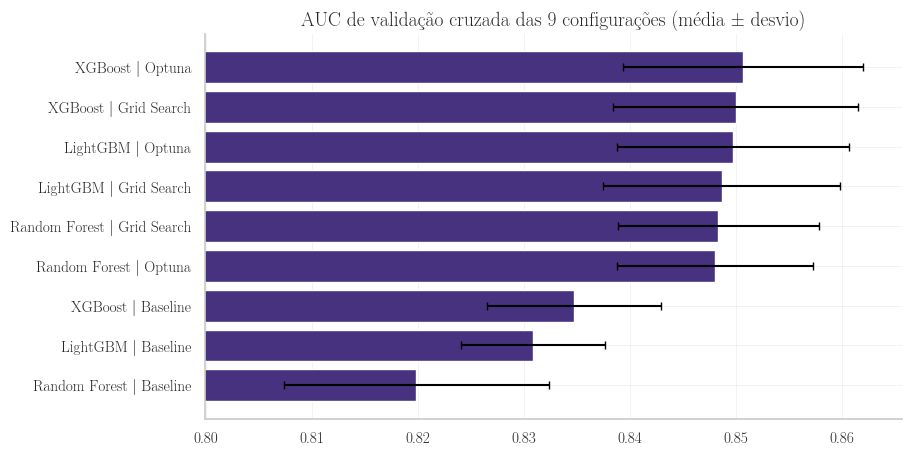

In [ ]:
# Regra de escolha (definida só com treino + validação cruzada):
# 1) pega a melhor AUC de CV;  2) considera "empatadas" as configs a menos de 1 desvio-padrão do folds
#    (diferença menor que a variação natural entre folds);  3) entre as empatadas, escolhe a de menor gap treino-CV.
melhor_auc = tab_final["auc_cv"].max()
margem = tab_final.loc[tab_final["auc_cv"].idxmax(), "auc_cv_std"]
empatadas = tab_final[tab_final["auc_cv"] >= melhor_auc - margem].sort_values("gap")
print(f"Melhor AUC CV: {melhor_auc:.4f} | margem de empate (1 desvio): {margem:.4f}")
display(empatadas[["auc_treino", "auc_cv", "auc_cv_std", "gap", "tempo_fit_s"]].round(4))

ESCOLHIDA = empatadas.index[0]
NOME_FINAL, ESTRATEGIA_FINAL = tab_final.loc[ESCOLHIDA, "modelo"], tab_final.loc[ESCOLHIDA, "estratégia"]
PARAMS_FINAIS = configuracoes[(NOME_FINAL, ESTRATEGIA_FINAL)]
print("\nConfiguração escolhida para o teste final:", ESCOLHIDA)
print("Hiperparâmetros:", PARAMS_FINAIS)

# Gráfico de apoio: as 9 configs lado a lado
ordem = tab_final.sort_values("auc_cv")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ordem.index, ordem["auc_cv"], xerr=ordem["auc_cv_std"], capsize=3)
ax.set_xlim(ordem["auc_cv"].min() - 0.02, ordem["auc_cv"].max() + 0.015)
ax.set_title("AUC de validação cruzada das 9 configurações (média ± desvio)")
plt.show()

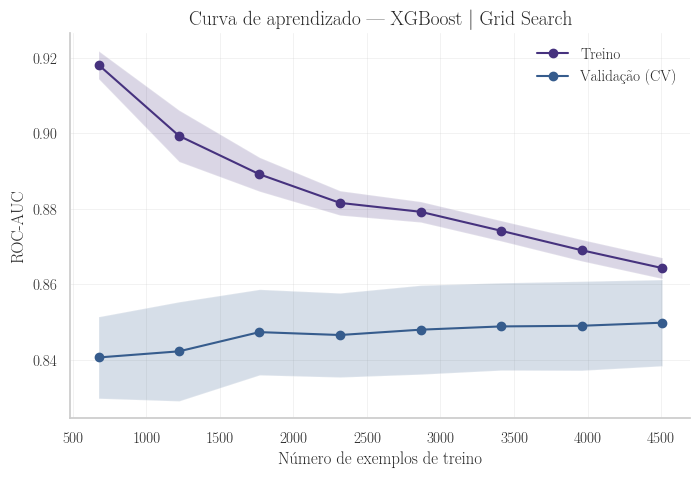

No maior tamanho: treino = 0.8643 | validação = 0.8498 | gap = 0.0145
Ganho da validação entre o menor e o maior tamanho: +0.0092


In [ ]:
# 6.2 Curva de aprendizado da configuração escolhida
pipe_final_cv = montar_pipeline(construir_modelo(NOME_FINAL, PARAMS_FINAIS))
tamanhos, treino_sc, val_sc = learning_curve(
    pipe_final_cv, X_train, y_train, cv=cv, scoring=METRICA_PRINCIPAL,
    train_sizes=np.linspace(0.15, 1.0, 8), random_state=SEED,
)
fig, ax = plt.subplots(figsize=(8, 5))
for valores, rotulo in [(treino_sc, "Treino"), (val_sc, "Validação (CV)")]:
    media, desvio = valores.mean(axis=1), valores.std(axis=1)
    ax.plot(tamanhos, media, "o-", label=rotulo)
    ax.fill_between(tamanhos, media - desvio, media + desvio, alpha=0.2)
ax.set_xlabel("Número de exemplos de treino"); ax.set_ylabel("ROC-AUC")
ax.set_title(f"Curva de aprendizado — {ESCOLHIDA}"); ax.legend()
plt.show()
print(f"No maior tamanho: treino = {treino_sc[-1].mean():.4f} | validação = {val_sc[-1].mean():.4f} | gap = {treino_sc[-1].mean() - val_sc[-1].mean():.4f}")
print(f"Ganho da validação entre o menor e o maior tamanho: {val_sc[-1].mean() - val_sc[0].mean():+.4f}")

**Overfitting e underfitting.**
- **Baselines:** gaps de 0,14–0,18 → sobreajuste forte (ver Exercício 4).
- **Após o tuning:** os gaps caíram para 0,014–0,036; o tuning corrigiu o sobreajuste sem perder desempenho de validação (que subiu de ~0,83 para ~0,85).
- **Curva de aprendizado (modelo escolhido):** as curvas de treino e validação ficam **próximas** (gap ≈ 0,015 com todos os dados), sem a separação típica de overfitting. A validação ainda sobe um pouco (+0,009 do menor ao maior tamanho) e tende a estabilizar perto de 0,85: mais dados ajudariam pouco. Como o treino também não é altíssimo (≈ 0,86), o modelo é simples e o limite parece vir das **informações disponíveis nas variáveis**, não de sobreajuste. Conclusão: **boa generalização**, com leve limitação de capacidade (mais perto de um pequeno *underfitting* do que de *overfitting*).
- **Variabilidade entre folds:** desvio-padrão ≈ 0,012, razoável para ~5,6 mil exemplos.

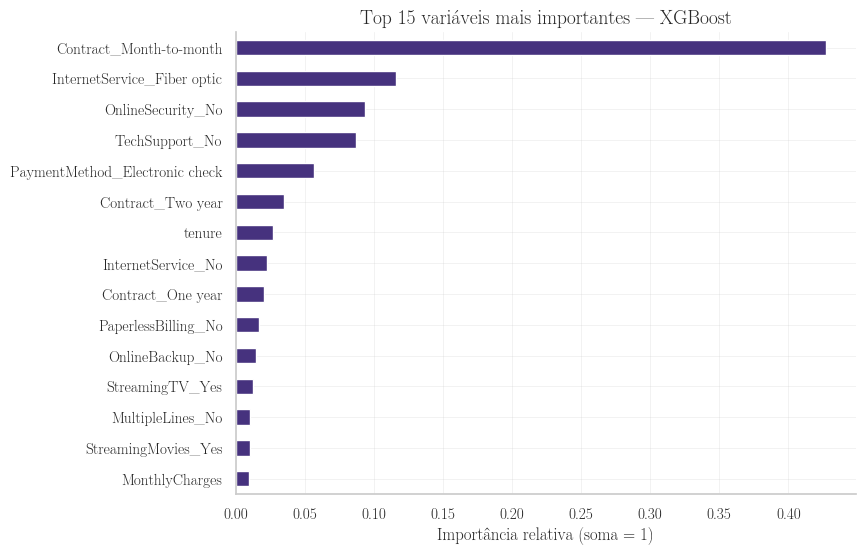

Importância somada por variável original (top 8):
Contract            0.483
InternetService     0.143
OnlineSecurity      0.094
TechSupport         0.093
PaymentMethod       0.057
tenure              0.027
PaperlessBilling    0.017
OnlineBackup        0.015


In [ ]:
# 6.3 Importância das variáveis (modelo escolhido treinado em todo o treino) — o teste continua isolado
pipe_exploracao = clone(pipe_final_cv).fit(X_train, y_train)
nomes_features = pipe_exploracao.named_steps["prep"].get_feature_names_out()
nomes_features = [n.replace("num__", "").replace("cat__", "") for n in nomes_features]
importancias = pd.Series(pipe_exploracao.named_steps["modelo"].feature_importances_, index=nomes_features)
importancias = importancias / importancias.sum()

fig, ax = plt.subplots(figsize=(8, 6))
importancias.sort_values().tail(15).plot(kind="barh", ax=ax)
ax.set_title(f"Top 15 variáveis mais importantes — {NOME_FINAL}")
ax.set_xlabel("Importância relativa (soma = 1)")
plt.show()

# As variáveis one-hot dividem a importância de uma mesma coluna original: somamos por coluna original
def coluna_original(nome):
    for c in cols_cat:
        if nome.startswith(c + "_"):
            return c
    return nome
imp_agrupada = importancias.groupby(coluna_original).sum().sort_values(ascending=False)
print("Importância somada por variável original (top 8):")
print(imp_agrupada.head(8).round(3).to_string())

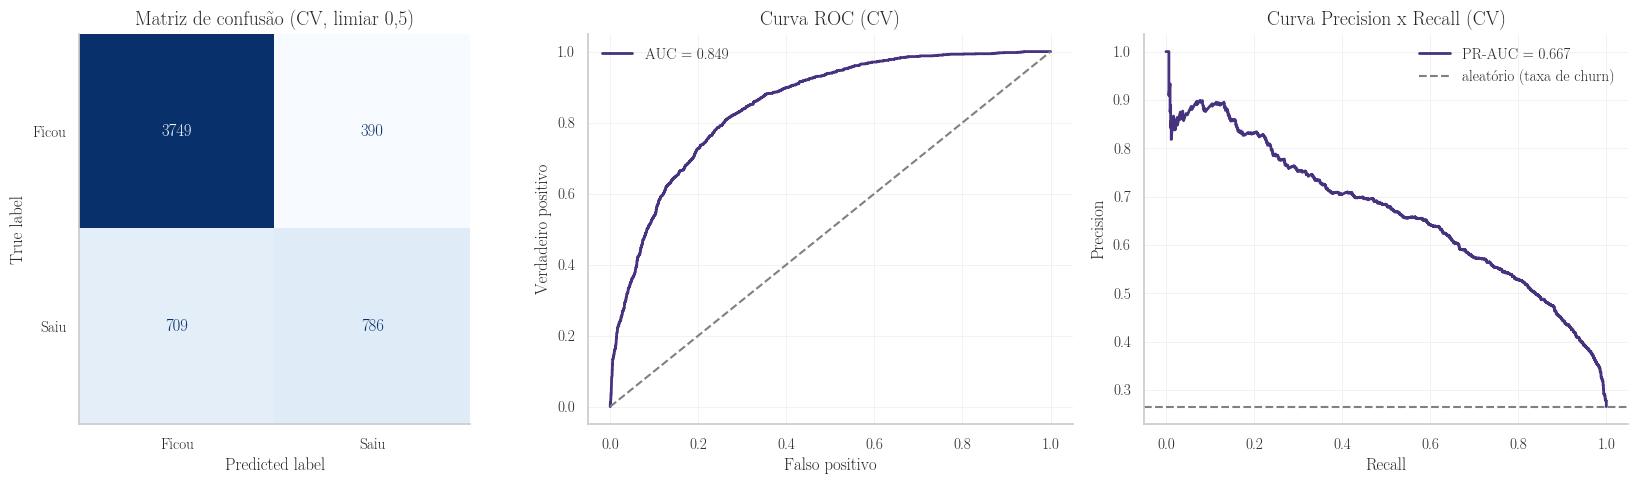

Matriz (CV): VN=3749 FP=390 FN=709 VP=786
Recall (CV, limiar 0,5) = 0.526 | Precision = 0.668


In [ ]:
# Gráficos de desempenho (classificação): previsões "out-of-fold" no TREINO (cada linha é prevista por um modelo que não a viu)
proba_oof = cross_val_predict(pipe_final_cv, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
pred_oof = (proba_oof >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, pred_oof), display_labels=["Ficou", "Saiu"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão (CV, limiar 0,5)"); axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_train, proba_oof)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_train, proba_oof):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray"); axes[1].set_xlabel("Falso positivo"); axes[1].set_ylabel("Verdadeiro positivo")
axes[1].set_title("Curva ROC (CV)"); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_train, proba_oof)
axes[2].plot(rec, prec, lw=2, label=f"PR-AUC = {average_precision_score(y_train, proba_oof):.3f}")
axes[2].axhline(y_train.mean(), ls="--", color="gray", label="aleatório (taxa de churn)")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision"); axes[2].set_title("Curva Precision x Recall (CV)"); axes[2].legend()
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_train, pred_oof).ravel()
print(f"Matriz (CV): VN={tn} FP={fp} FN={fn} VP={tp}")
print(f"Recall (CV, limiar 0,5) = {tp/(tp+fn):.3f} | Precision = {tp/(tp+fp):.3f}")

**Importância das variáveis e desempenho.**
- **Contrato** concentra sozinho ~48% da importância; depois vêm **InternetService** (~14%), **OnlineSecurity** (~9%), **TechSupport** (~9%) e **PaymentMethod** (~6%). Isso é **coerente com a exploração dos dados** (Exercício 2): contrato mensal, fibra óptica, ausência de segurança/suporte e pagamento por *electronic check* concentram o churn.
- `tenure` aparece com importância baixa (~3%) porque, com árvores rasas, o tipo de contrato já captura boa parte da informação de permanência — variáveis correlacionadas "dividem" a importância. Importância não é causalidade.
- **Desempenho (previsões de validação cruzada, limiar 0,5):** das 1.495 pessoas que cancelaram, o modelo identificou 786 (recall ≈ 0,53), e dos 1.176 alertas, 786 foram corretos (precision ≈ 0,67). A curva ROC é bem acima da diagonal e a curva Precision × Recall fica bem acima da taxa-base de 26,5%. **Implicação prática:** com limiar 0,5 o modelo deixa passar quase metade dos clientes que vão sair; se o objetivo do negócio for não perder clientes, vale **baixar o limiar** (aceitando mais alarmes falsos).

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

**Resposta do aluno — Exercício 7**

A partir daqui o conjunto de teste é usado **uma única vez**, para avaliar a configuração já escolhida (XGBoost + Grid Search).

Modelo final: XGBoost | Grid Search


,Teste,CV (média),Diferença (Teste - CV)
roc_auc,0.8456,0.8500,-0.0044
pr_auc,0.6638,0.6700,-0.0061
f1,0.5904,0.5885,0.0019
recall,0.5241,0.5258,-0.0017
precision,0.6759,0.6692,0.0067
accuracy,0.8070,0.8049,0.0020


AUC no teste = 0.8456 | CV = 0.8500 ± 0.0116


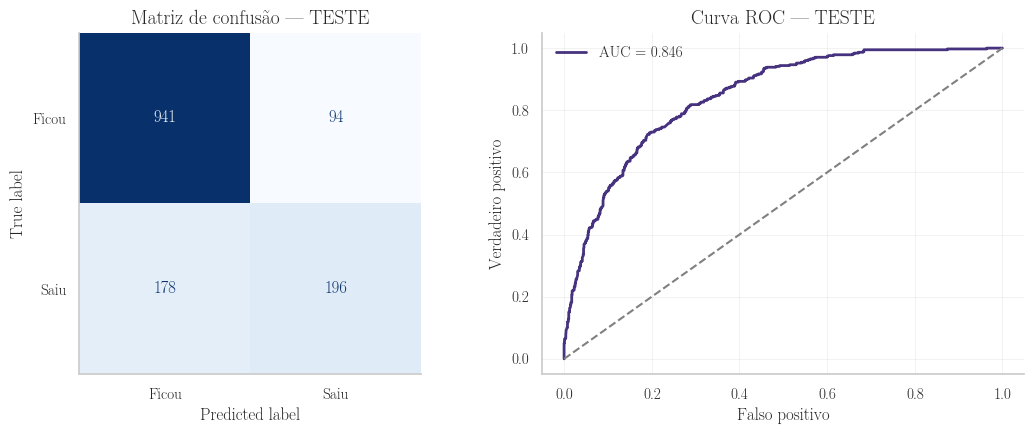

In [ ]:
# 7.1 AVALIAÇÃO FINAL — única vez que o teste é usado.
# Refaz o treino da configuração escolhida com TODO o treino e avalia no teste.
modelo_final = montar_pipeline(construir_modelo(NOME_FINAL, PARAMS_FINAIS))
modelo_final.fit(X_train, y_train)

proba_teste = modelo_final.predict_proba(X_test)[:, 1]
pred_teste = modelo_final.predict(X_test)

metricas_teste = {
    "roc_auc": roc_auc_score(y_test, proba_teste),
    "pr_auc": average_precision_score(y_test, proba_teste),
    "f1": f1_score(y_test, pred_teste),
    "recall": recall_score(y_test, pred_teste),
    "precision": precision_score(y_test, pred_teste),
    "accuracy": accuracy_score(y_test, pred_teste),
}
cv_ref = tab_final.loc[ESCOLHIDA]
comparativo = pd.DataFrame({
    "Teste": metricas_teste,
    "CV (média)": {"roc_auc": cv_ref["auc_cv"], "pr_auc": cv_ref["pr_auc_cv"], "f1": cv_ref["f1_cv"],
                   "recall": cv_ref["recall_cv"], "precision": cv_ref["precision_cv"], "accuracy": cv_ref["acc_cv"]},
})
comparativo["Diferença (Teste - CV)"] = comparativo["Teste"] - comparativo["CV (média)"]
print("Modelo final:", ESCOLHIDA)
display(comparativo.round(4))
print(f"AUC no teste = {metricas_teste['roc_auc']:.4f} | CV = {cv_ref['auc_cv']:.4f} ± {cv_ref['auc_cv_std']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_teste), display_labels=["Ficou", "Saiu"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão — TESTE"); axes[0].grid(False)
fpr, tpr, _ = roc_curve(y_test, proba_teste)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {metricas_teste['roc_auc']:.3f}"); axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Curva ROC — TESTE"); axes[1].set_xlabel("Falso positivo"); axes[1].set_ylabel("Verdadeiro positivo"); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretação do teste final.** No teste, a **AUC foi 0,8456** contra 0,8500 ± 0,0116 na validação cruzada: diferença de apenas −0,004, **bem dentro de 1 desvio-padrão** dos folds. As demais métricas também batem com a validação (F1 0,590 × 0,589; recall 0,524 × 0,526; precision 0,676 × 0,669; acurácia 0,807 × 0,805). Portanto a generalização observada é **compatível com o desenvolvimento**: não houve sinal de sobreajuste à validação, e a acurácia (80,7%) supera a referência de 73,5% da classe majoritária. A pequena queda da AUC é esperada, já que a validação foi usada para escolher hiperparâmetros (leve otimismo).

In [ ]:
# 7.2 Teste de consistência: 6 observações do teste (nenhuma participou do treino)
res = X_test.copy()
res["y_real"] = y_test
res["proba_churn"] = proba_teste
res["y_previsto"] = pred_teste
res["erro_abs"] = (res["y_real"] - res["proba_churn"]).abs()

acertos = res[res["y_real"] == res["y_previsto"]]
erros = res[res["y_real"] != res["y_previsto"]]
casos = {
    "Acerto fácil — churn (alta prob.)": acertos[acertos["y_real"] == 1]["proba_churn"].idxmax(),
    "Acerto fácil — permanência (baixa prob.)": acertos[acertos["y_real"] == 0]["proba_churn"].idxmin(),
    "Acerto — churn com prob. moderada": (acertos[acertos["y_real"] == 1]["proba_churn"] - 0.6).abs().idxmin(),
    "Difícil — perto do limiar (0,5)": (res["proba_churn"] - 0.5).abs().idxmin(),
    "Difícil — falso negativo (churn não detectado)": erros[erros["y_real"] == 1]["proba_churn"].idxmin(),
    "Difícil — falso positivo (alarme falso)": erros[erros["y_real"] == 0]["proba_churn"].idxmax(),
}
colunas_resumo = ["Contract", "tenure", "MonthlyCharges", "InternetService", "PaymentMethod", "TechSupport",
                  "y_real", "y_previsto", "proba_churn"]
casos_df = res.loc[list(casos.values()), colunas_resumo].copy()
casos_df.insert(0, "caso", list(casos.keys()))
casos_df["proba_churn"] = casos_df["proba_churn"].round(4)
casos_df

,caso,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod,TechSupport,y_real,y_previsto,proba_churn
3380,Acerto fácil — churn (alta prob.),Month-to-month,1,95.10,Fiber optic,Electronic check,No,1,1,0.9135
4201,Acerto fácil — permanência (baixa prob.),Two year,72,19.55,No,Bank transfer (automatic),No internet service,0,0,0.0039
880,Acerto — churn com prob. moderada,Month-to-month,10,110.10,Fiber optic,Electronic check,Yes,1,1,0.5993
1472,"Difícil — perto do limiar (0,5)",Month-to-month,13,74.40,Fiber optic,Credit card (automatic),No,1,1,0.5003
4513,Difícil — falso negativo (churn não detectado),Two year,72,92.45,DSL,Credit card (automatic),Yes,1,0,0.0088
2036,Difícil — falso positivo (alarme falso),Month-to-month,1,74.30,Fiber optic,Electronic check,No,0,1,0.8349


**Interpretação do teste de consistência.**
- **Acertos claros:** o cliente `3380` (contrato mensal, fibra óptica, 1 mês de casa, *electronic check*, sem suporte) recebeu **91%** de probabilidade de churn e de fato saiu; o `4201` (contrato de 2 anos, 72 meses, conta baixa) recebeu **0,4%** e ficou. Ambos seguem exatamente os padrões vistos na exploração e na importância das variáveis.
- **Casos difíceis:** (i) o cliente `1472` ficou na fronteira (p ≈ 0,50) — o modelo não tem segurança e acertou "por pouco"; (ii) o `4513` é um **falso negativo**: contrato de 2 anos, 72 meses, DSL, com suporte — perfil de cliente fiel, mas que saiu; é um caso que o modelo não tem como antecipar só com essas variáveis (p ≈ 0,9%); (iii) o `2036` é um **falso positivo**: perfil muito parecido com o de clientes que saem (mensal, 1 mês, fibra, *electronic check*), mas que permaneceu (p ≈ 83%).
- **Conclusão:** os erros ocorrem em perfis atípicos ou ambíguos, e as probabilidades fazem sentido em relação ao padrão aprendido.

In [ ]:
# 7.3 Salva os artefatos usados pelo Streamlit: o MESMO pipeline (pré-processamento + modelo) e metadados
os.makedirs("model", exist_ok=True)
joblib.dump(modelo_final, "model/pipeline_final.joblib")

metadados = {
    "modelo_final": ESCOLHIDA,
    "hiperparametros": {k: (v.item() if hasattr(v, "item") else v) for k, v in PARAMS_FINAIS.items()},
    "colunas_entrada": list(X_train.columns),
    "colunas_numericas": cols_num,
    "colunas_categoricas": cols_cat,
    "opcoes_categoricas": {c: sorted(X_train[c].unique().tolist()) for c in cols_cat},
    "faixas_numericas": {c: {"min": float(X_train[c].min()), "max": float(X_train[c].max()),
                             "mediana": float(X_train[c].median())} for c in cols_num},
    "metricas_teste": {k: float(v) for k, v in metricas_teste.items()},
    "auc_cv": float(cv_ref["auc_cv"]), "auc_cv_std": float(cv_ref["auc_cv_std"]),
    "limiar": 0.5,
}
with open("model/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

# casos de consistência completos (todas as colunas de entrada), usados também pelo app e pelo teste de paridade
completo = res.loc[list(casos.values()), list(X_train.columns) + ["y_real", "y_previsto", "proba_churn"]].copy()
completo.insert(0, "caso", list(casos.keys()))
completo.insert(0, "indice_original", completo.index)
completo.to_csv("data/casos_consistencia.csv", index=False)

# Tabelas de resultado para o README
tab_final[colunas_mostrar].round(4).to_csv("model/comparacao_9_configuracoes.csv")
print("Arquivos salvos: model/pipeline_final.joblib, model/metadata.json, data/casos_consistencia.csv")

Arquivos salvos: model/pipeline_final.joblib, model/metadata.json, data/casos_consistencia.csv


In [ ]:
# 7.4 Teste de paridade (lado do notebook): recarrega o artefato salvo e prevê o caso escolhido
pipeline_carregado = joblib.load("model/pipeline_final.joblib")

CASO_PARIDADE = list(casos.keys())[0]                       # caso escolhido para a conferência
idx = casos[CASO_PARIDADE]
entrada = X_test.loc[[idx]]
proba_notebook = float(pipeline_carregado.predict_proba(entrada)[0, 1])
classe_notebook = int(pipeline_carregado.predict(entrada)[0])

print("Caso:", CASO_PARIDADE, "| índice original:", idx)
print("Entradas para digitar no Streamlit:")
print(entrada.iloc[0].to_string())
print(f"\n>>> NOTEBOOK: probabilidade de churn = {proba_notebook:.4f} | classe = {classe_notebook} | y real = {int(y_test.loc[idx])}")
assert abs(proba_notebook - float(res.loc[idx, "proba_churn"])) < 1e-12, "artefato salvo diverge do modelo em memória"
print("OK: o artefato salvo reproduz exatamente a previsão do modelo em memória.")

Caso: Acerto fácil — churn (alta prob.) | índice original: 3380
Entradas para digitar no Streamlit:
gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1

>>> NOTEBOOK: probabilidade de churn = 0.9135 | classe = 1 | y real = 1
OK: o artefato salvo reproduz exatamente a previsão do modelo em memória.


**Teste de paridade notebook × Streamlit.**
- **Caso escolhido:** cliente `3380` ("Acerto fácil — churn"). Probabilidade no notebook (pipeline carregado do arquivo salvo): **0,9135 (91,35%)**, classe 1.
- **Verificação automatizada:** `tests/test_paridade.py` preenche no app (via `streamlit.testing`) as mesmas entradas dos **6 casos** acima, aperta *Prever* e compara com o pipeline: os 6 casos coincidiram (ex.: caso 3380 → app 91,35%; caso 1472 → 50,03%).
- **O app usa o mesmo artefato** (`model/pipeline_final.joblib`) — pré-processamento e modelo no mesmo objeto —, sem nenhuma reimplementação do tratamento de dados.
- **Conferência manual na URL pública:** abrir o app publicado, escolher o caso "Acerto fácil — churn" (ou digitar as entradas impressas acima) e verificar **91,35%**.

In [ ]:
URL_GITHUB = "https://github.com/dnlduarte/checkpoint5-DataScience-fiap.git"
URL_STREAMLIT = "https://checkpoint5-datascience-fiap-cjkpabyy69pbmf4r3dna95.streamlit.app/"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: https://github.com/COLE-AQUI-O-LINK-DO-REPOSITORIO
Streamlit: https://COLE-AQUI-O-LINK-DO-APP.streamlit.app


**Links finais:** substitua as duas URLs abaixo pelos endereços reais antes de entregar.

**Síntese para a apresentação (10 min):** problema de churn → base e alvo → wrangling (`TotalCharges`) e variável removida → protocolo (split 80/20, CV 5 folds, AUC) → baselines com overfitting forte → Grid × Optuna (empate técnico) → XGBoost + Grid escolhido pelo menor gap → teste AUC 0,846 compatível com CV → demonstração do Streamlit e paridade.

<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).